[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USERNAME/REPO/blob/main/meeting10-11/retrieval_eval_demo.ipynb)


# Meeting 10 — Evaluating Retrieval (demo)

Companion notebook to **Meeting 10 — Evaluating retrieval & the four design knobs**.

We re-implement every metric and every ablation from the slides on **SQuAD 1.1 dev**, and finish with the leaderboard and the recall@k curves.

**How to run:**

- **Google Colab** — `Runtime → Change runtime type → T4 GPU`, then `Run all`. ~10 minutes.
- **Local CPU** — `Run all` in Jupyter / VS Code. ~30 minutes.

The first cell installs everything; subsequent cells assume those imports.


In [1]:
# Install dependencies (Colab-friendly; harmless on a local env that already has them)
%pip install -q -U datasets sentence-transformers faiss-cpu rank_bm25 matplotlib pandas


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, math, time, json, random
from collections import defaultdict
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch: {torch.__version__}")
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")


Torch: 2.5.1+cu124
Device: cpu


## Part 1 — Load SQuAD 1.1 dev and build the document corpus

We turn SQuAD into a **retrieval benchmark**:

1. Concatenate paragraphs by article — each article becomes one "document"
2. For each question, remember the **gold paragraph** (and the answer span inside it)
3. At eval time, a retrieved chunk is **relevant** to a question if it **contains the answer text**

This sidesteps the question of "how much paragraph overlap counts" — a chunk is relevant iff the answer is in it.


In [2]:
ds = load_dataset("rajpurkar/squad", split="validation")
print(f"Total questions: {len(ds):,}")

# Build per-article corpus: dedupe paragraphs, preserve order of first appearance
articles = {}                    # title -> {"paragraphs": [text, ...]}
paragraph_index = {}             # (title, paragraph_text) -> paragraph_id (int)
questions = []                   # list of dicts: id, question, answer, title, gold_para_id

for ex in ds:
    title, ctx = ex["title"], ex["context"]
    if title not in articles:
        articles[title] = {"paragraphs": []}
    art = articles[title]
    if (title, ctx) not in paragraph_index:
        para_id = len(art["paragraphs"])
        art["paragraphs"].append(ctx)
        paragraph_index[(title, ctx)] = para_id
    gold_para_id = paragraph_index[(title, ctx)]
    questions.append({
        "id":            ex["id"],
        "question":      ex["question"],
        "answer":        ex["answers"]["text"][0],
        "title":         title,
        "gold_para_id":  gold_para_id,
    })

n_articles  = len(articles)
n_paragraphs = sum(len(a["paragraphs"]) for a in articles.values())
print(f"Articles:   {n_articles}")
print(f"Paragraphs: {n_paragraphs:,}")
print(f"Questions:  {len(questions):,}")


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Total questions: 10,570
Articles:   48
Paragraphs: 2,067
Questions:  10,570


In [4]:
ds[0]

{'id': '56be4db0acb8001400a502ec',
 'title': 'Super_Bowl_50',
 'context': 'Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi\'s Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.',
 'question': 'Which NFL team represented the AFC at Super Bowl 50?',
 'answers': {'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'],


## Part 2 — Implement the metrics

We implement five metrics from the slides:

- **recall@k**, **hit@k**, **precision@k**
- **MRR** (Mean Reciprocal Rank — only the *first* relevant doc)
- **nDCG@k** (with binary relevance — graded relevance is straightforward to extend)

For SQuAD, every question has exactly one gold paragraph, so a chunk is **either relevant or not** to a question. In that single-relevant-doc setting, **recall@k ≡ hit@k** (as we noted in the deck).

Even so, we compute both — they diverge on multi-doc benchmarks (M11 will use SciFact for that).


In [4]:
def recall_at_k(retrieved_ids, relevant_set, k):
    if not relevant_set: return 0.0
    return len(set(retrieved_ids[:k]) & relevant_set) / len(relevant_set)

def hit_at_k(retrieved_ids, relevant_set, k):
    return 1.0 if (set(retrieved_ids[:k]) & relevant_set) else 0.0

def precision_at_k(retrieved_ids, relevant_set, k):
    if k == 0: return 0.0
    return len(set(retrieved_ids[:k]) & relevant_set) / k

def reciprocal_rank(retrieved_ids, relevant_set):
    for i, doc in enumerate(retrieved_ids, start=1):
        if doc in relevant_set:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved_ids, relevant_set, k):
    # Binary relevance: rel_i = 1 if retrieved_ids[i] in relevant_set else 0
    dcg = 0.0
    for i, doc in enumerate(retrieved_ids[:k], start=1):
        if doc in relevant_set:
            dcg += 1.0 / math.log2(i + 1)
    n_rel = min(k, len(relevant_set))
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, n_rel + 1))
    return (dcg / idcg) if idcg > 0 else 0.0

def evaluate(retrieved_lists, relevant_sets, k_values=(1,3,5,10)):
    out = {}
    for k in k_values:
        out[f"recall@{k}"]    = float(np.mean([recall_at_k(r, s, k)    for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"hit@{k}"]       = float(np.mean([hit_at_k(r, s, k)       for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"precision@{k}"] = float(np.mean([precision_at_k(r, s, k) for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"ndcg@{k}"]      = float(np.mean([ndcg_at_k(r, s, k)      for r, s in zip(retrieved_lists, relevant_sets)]))
    out["mrr"] = float(np.mean([reciprocal_rank(r, s) for r, s in zip(retrieved_lists, relevant_sets)]))
    return out

# Sanity check on synthetic data
relevant = {"d_42"}
retrieved = ["d_17", "d_42", "d_99", "d_3", "d_8"]
print("Sanity check:")
print(f"  recall@5    = {recall_at_k(retrieved, relevant, 5):.3f}  (expect 1.000)")
print(f"  hit@5       = {hit_at_k(retrieved, relevant, 5):.3f}  (expect 1.000)")
print(f"  precision@5 = {precision_at_k(retrieved, relevant, 5):.3f}  (expect 0.200)")
print(f"  MRR         = {reciprocal_rank(retrieved, relevant):.3f}  (expect 0.500)")
print(f"  nDCG@5      = {ndcg_at_k(retrieved, relevant, 5):.3f}  (expect 0.631)")


Sanity check:
  recall@5    = 1.000  (expect 1.000)
  hit@5       = 1.000  (expect 1.000)
  precision@5 = 0.200  (expect 0.200)
  MRR         = 0.500  (expect 0.500)
  nDCG@5      = 0.631  (expect 0.631)


## Part 3 — Chunking utilities and the baseline pipeline

We need to:

1. **Chunk** each article's text into pieces (size + overlap configurable)
2. **Track each chunk's character offsets** within its source article — so we can mark a chunk relevant iff the answer text falls inside it

The chunker below is **whitespace-token-based** with optional overlap. Students can swap in `tiktoken`, sentence-aware splitting, or a recursive splitter as an exercise.


In [5]:
def chunk_article(text, size, overlap):
    # Split text into chunks of ~size whitespace tokens with `overlap` token overlap.
    # Returns a list of dicts with text + character offsets in the source.
    assert overlap < size, "overlap must be smaller than chunk size"
    tokens, offsets = [], []
    i = 0
    while i < len(text):
        while i < len(text) and text[i].isspace():
            i += 1
        start = i
        while i < len(text) and not text[i].isspace():
            i += 1
        if i > start:
            tokens.append(text[start:i])
            offsets.append((start, i))
    if not tokens:
        return []
    chunks, step = [], size - overlap
    s = 0
    while s < len(tokens):
        e = min(s + size, len(tokens))
        char_start = offsets[s][0]
        char_end   = offsets[e - 1][1]
        chunks.append({"text": text[char_start:char_end], "char_start": char_start, "char_end": char_end})
        if e == len(tokens):
            break
        s += step
    return chunks


def build_index(articles, chunk_size, overlap):
    # For each article, build chunks + remember which paragraphs each chunk overlaps.
    chunks = []
    for title, art in articles.items():
        parts, para_ranges = [], []
        cursor = 0
        for pid, para in enumerate(art["paragraphs"]):
            if parts:
                parts.append("\n\n")
                cursor += 2
            parts.append(para)
            para_ranges.append((pid, cursor, cursor + len(para)))
            cursor += len(para)
        full_text = "".join(parts)
        for c in chunk_article(full_text, chunk_size, overlap):
            overlapping = {pid for pid, s, e in para_ranges
                           if not (c["char_end"] <= s or c["char_start"] >= e)}
            chunks.append({
                "title":     title,
                "text":      c["text"],
                "para_ids":  overlapping,
            })
    texts = [c["text"] for c in chunks]
    return chunks, texts


# Sanity check
demo_chunks, demo_texts = build_index(articles, chunk_size=256, overlap=0)
print(f"Built {len(demo_chunks):,} chunks at chunk_size=256, overlap=0")
print(f"Avg chunk length: {np.mean([len(t) for t in demo_texts]):.0f} chars")


Built 1,016 chunks at chunk_size=256, overlap=0
Avg chunk length: 1578 chars


### Build a query → relevant-chunk mapping (cached per chunking config)

Relevance lookup is the slow part (O(questions × chunks)). We do it once per chunking config and cache.


In [6]:
def build_relevance_map(questions, chunks):
    # For each question, return the set of chunk ids that contain the answer text
    # AND come from the same article.
    by_title = defaultdict(list)
    for cid, c in enumerate(chunks):
        by_title[c["title"]].append((cid, c["text"]))
    relmap = []
    for q in questions:
        ans = q["answer"]; title = q["title"]
        rel = {cid for cid, txt in by_title.get(title, []) if ans in txt}
        relmap.append(rel)
    return relmap

def filter_questions_with_evidence(questions, relmap):
    keep_q, keep_r, dropped = [], [], 0
    for q, r in zip(questions, relmap):
        if r:
            keep_q.append(q); keep_r.append(r)
        else:
            dropped += 1
    return keep_q, keep_r, dropped


relmap_demo = build_relevance_map(questions, demo_chunks)
q_demo, r_demo, dropped = filter_questions_with_evidence(questions, relmap_demo)
print(f"Questions with at least one relevant chunk: {len(q_demo):,}  (dropped {dropped})")
print(f"Avg # relevant chunks per question: {np.mean([len(r) for r in r_demo]):.2f}")


Questions with at least one relevant chunk: 10,511  (dropped 59)
Avg # relevant chunks per question: 2.07


### Embed-and-search pipeline

We wrap the embed-and-search loop into one function that caches by config so ablations don't re-embed unnecessarily.

For SQuAD-sized corpora (~1k–4k chunks), **flat search** is the right default. We bring in FAISS later for the ANN ablation.


In [7]:
def embed_texts(model, texts, batch_size=64, normalize=True):
    embs = model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                        convert_to_numpy=True, normalize_embeddings=normalize)
    return embs.astype(np.float32)


def flat_search(query_embs, doc_embs, top_k=10):
    # Returns (n_queries, top_k) of doc indices ranked by descending dot product.
    sims = query_embs @ doc_embs.T
    if top_k >= sims.shape[1]:
        return np.argsort(-sims, axis=1)
    idx = np.argpartition(-sims, top_k, axis=1)[:, :top_k]
    order = np.argsort(-np.take_along_axis(sims, idx, 1), axis=1)
    return np.take_along_axis(idx, order, 1)


CACHE = {"chunks": {}, "models": {}, "doc_embs": {}, "embed_time": {}}

def get_chunks(chunk_size, overlap):
    key = (chunk_size, overlap)
    if key not in CACHE["chunks"]:
        chunks, texts = build_index(articles, chunk_size, overlap)
        relmap = build_relevance_map(questions, chunks)
        q_eval, r_eval, _ = filter_questions_with_evidence(questions, relmap)
        CACHE["chunks"][key] = (chunks, texts, q_eval, r_eval)
    return CACHE["chunks"][key]

def get_model(name):
    if name not in CACHE["models"]:
        CACHE["models"][name] = SentenceTransformer(name, device=DEVICE)
    return CACHE["models"][name]

def get_doc_embs(model_name, chunk_size, overlap, normalize=True):
    key = (model_name, chunk_size, overlap, normalize)
    if key not in CACHE["doc_embs"]:
        chunks, texts, _, _ = get_chunks(chunk_size, overlap)
        model = get_model(model_name)
        t0 = time.time()
        CACHE["doc_embs"][key] = embed_texts(model, texts, normalize=normalize)
        CACHE["embed_time"][key] = time.time() - t0
    return CACHE["doc_embs"][key]

def run_pipeline(model_name, chunk_size, overlap, top_k=10):
    chunks, texts, q_eval, r_eval = get_chunks(chunk_size, overlap)
    model = get_model(model_name)
    doc_embs = get_doc_embs(model_name, chunk_size, overlap)
    q_texts = [q["question"] for q in q_eval]
    query_embs = embed_texts(model, q_texts)
    t0 = time.time()
    top = flat_search(query_embs, doc_embs, top_k=top_k)
    query_ms = (time.time() - t0) / max(1, len(q_eval)) * 1000
    retrieved_lists = [list(top[i]) for i in range(len(q_eval))]
    metrics = evaluate(retrieved_lists, r_eval, k_values=(1,3,5,10))
    metrics["n_chunks"]    = len(chunks)
    metrics["n_questions"] = len(q_eval)
    metrics["query_ms"]    = query_ms
    return metrics, retrieved_lists, r_eval

print("Pipeline ready.")


Pipeline ready.


### Baseline run — the M9 configuration

`chunk_size=256, overlap=0, fixed-token chunking, all-MiniLM-L6-v2, flat, cosine.`

This number is the leftmost row of the leaderboard in the deck.


In [8]:
BASELINE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
baseline_metrics, baseline_lists, baseline_rel = run_pipeline(BASELINE_MODEL, chunk_size=256, overlap=0)

print("M9 baseline:")
for k in ["recall@1", "recall@5", "recall@10", "mrr", "ndcg@10"]:
    print(f"  {k:<12} {baseline_metrics[k]:.3f}")
print(f"  n_chunks    {baseline_metrics['n_chunks']}")
print(f"  query_ms    {baseline_metrics['query_ms']:.2f}")


M9 baseline:
  recall@1     0.395
  recall@5     0.668
  recall@10    0.774
  mrr          0.630
  ndcg@10      0.627
  n_chunks    1016
  query_ms    0.02


### Plot the recall@k curve for the baseline (k = 1 … 10)

This is **the main metric** for M10. Every ablation will overlay its curve on top of this baseline.


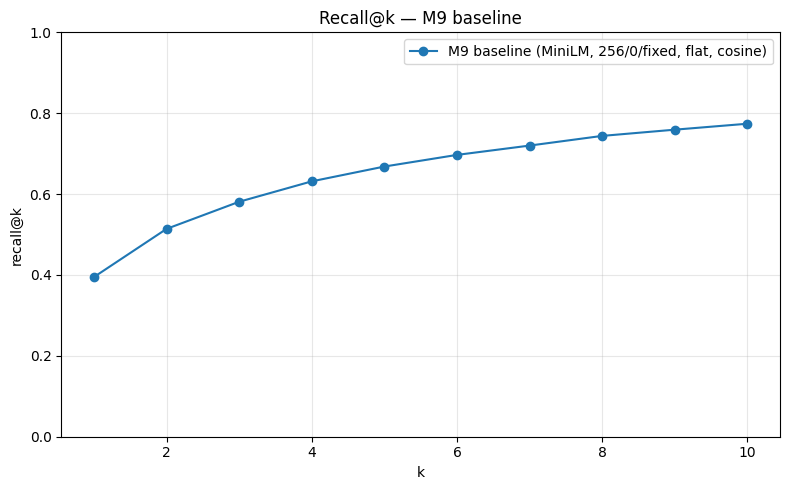

In [9]:
def recall_curve(retrieved_lists, relevant_sets, ks=range(1, 11)):
    return [float(np.mean([recall_at_k(r, s, k) for r, s in zip(retrieved_lists, relevant_sets)])) for k in ks]

def plot_curves(curves, title, ks=range(1, 11)):
    plt.figure(figsize=(8, 5))
    for label, ys in curves.items():
        plt.plot(list(ks), ys, marker='o', label=label)
    plt.xlabel("k"); plt.ylabel("recall@k")
    plt.title(title); plt.ylim(0, 1)
    plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

baseline_curve = recall_curve(baseline_lists, baseline_rel)
plot_curves({"M9 baseline (MiniLM, 256/0/fixed, flat, cosine)": baseline_curve},
            title="Recall@k — M9 baseline")


## Knob 1 — Chunking

We sweep `chunk_size` ∈ {128, 256, 512, 1024} with `overlap=0`, then `overlap` ∈ {0, 50, 100} at the winning chunk size. All other knobs held at the baseline (MiniLM-L6-v2, flat, cosine).


 chunk_size  overlap  recall@5  recall@10   mrr  ndcg@10  n_chunks  query_ms
        128        0     0.679      0.770 0.661    0.641      2007     0.049
        256        0     0.668      0.774 0.630    0.627      1016     0.017
        512        0     0.619      0.761 0.546    0.571       519     0.010
       1024        0     0.669      0.795 0.530    0.577       271     0.004


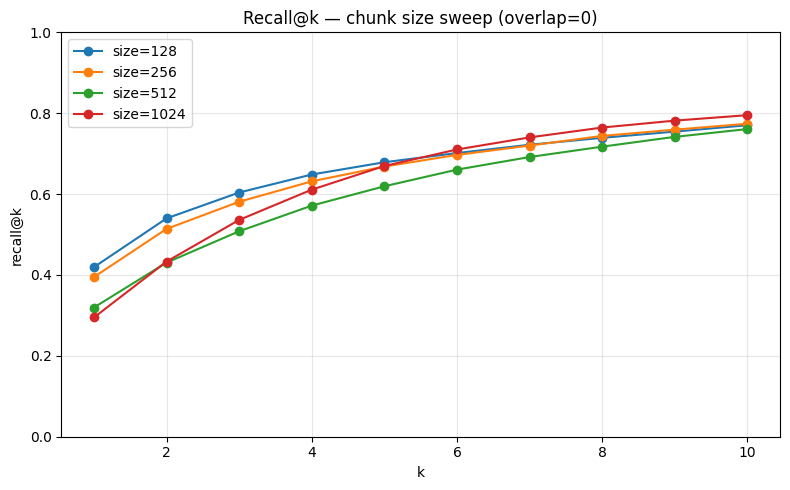

In [10]:
chunk_size_sweep = [128, 256, 512, 1024]
chunk_results, chunk_curves = [], {}
for cs in chunk_size_sweep:
    m, lists, rel = run_pipeline(BASELINE_MODEL, chunk_size=cs, overlap=0)
    chunk_results.append({
        "chunk_size": cs, "overlap": 0,
        "recall@5": m["recall@5"], "recall@10": m["recall@10"],
        "mrr": m["mrr"], "ndcg@10": m["ndcg@10"],
        "n_chunks": m["n_chunks"], "query_ms": m["query_ms"],
    })
    chunk_curves[f"size={cs}"] = recall_curve(lists, rel)

df = pd.DataFrame(chunk_results)
print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(chunk_curves, title="Recall@k — chunk size sweep (overlap=0)")


Best chunk size by recall@10: 1024
 chunk_size  overlap  recall@5  recall@10   mrr  n_chunks
       1024        0     0.669      0.795 0.530       271
       1024       50     0.642      0.784 0.532       280
       1024      100     0.635      0.781 0.533       295


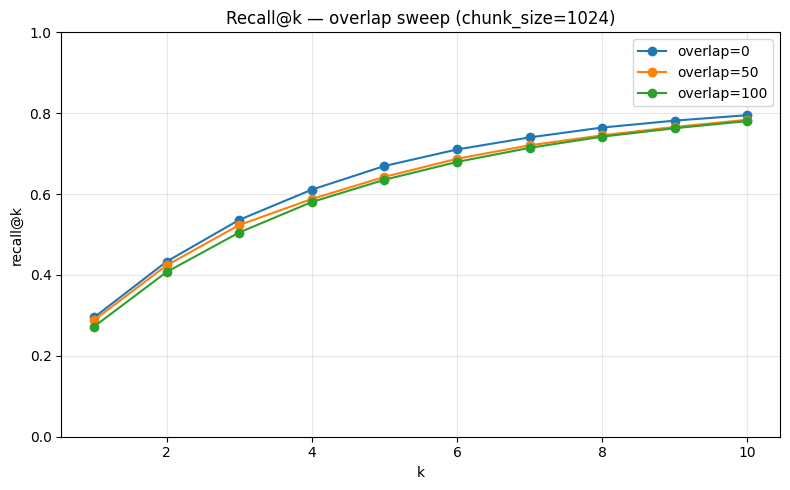

In [11]:
best_size = int(df.loc[df["recall@10"].idxmax(), "chunk_size"])
print(f"Best chunk size by recall@10: {best_size}")

overlap_sweep = [0, 50, 100]
overlap_results, overlap_curves = [], {}
for ov in overlap_sweep:
    if ov >= best_size:
        continue
    m, lists, rel = run_pipeline(BASELINE_MODEL, chunk_size=best_size, overlap=ov)
    overlap_results.append({
        "chunk_size": best_size, "overlap": ov,
        "recall@5": m["recall@5"], "recall@10": m["recall@10"],
        "mrr": m["mrr"], "n_chunks": m["n_chunks"],
    })
    overlap_curves[f"overlap={ov}"] = recall_curve(lists, rel)

df_ov = pd.DataFrame(overlap_results)
print(df_ov.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(overlap_curves, title=f"Recall@k — overlap sweep (chunk_size={best_size})")


In [12]:
best_overlap = int(df_ov.loc[df_ov["recall@10"].idxmax(), "overlap"])
print(f"Knob 1 winners: chunk_size={best_size}, overlap={best_overlap}")
KNOB1 = {"chunk_size": best_size, "overlap": best_overlap}


Knob 1 winners: chunk_size=1024, overlap=0


## Knob 2 — Embedding model

Four open models, on the Knob-1 winning chunking config. Index size = `n_chunks × dim × 4` bytes.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

            model  dim  recall@5  recall@10   mrr  index_MB  embed_s
 all-MiniLM-L6-v2  384     0.669      0.795 0.530     0.397    8.149
bge-small-en-v1.5  384     0.723      0.837 0.580     0.397   37.157
 bge-base-en-v1.5  768     0.745      0.858 0.599     0.794   99.460
       e5-base-v2  768     0.761      0.870 0.630     0.794  101.026


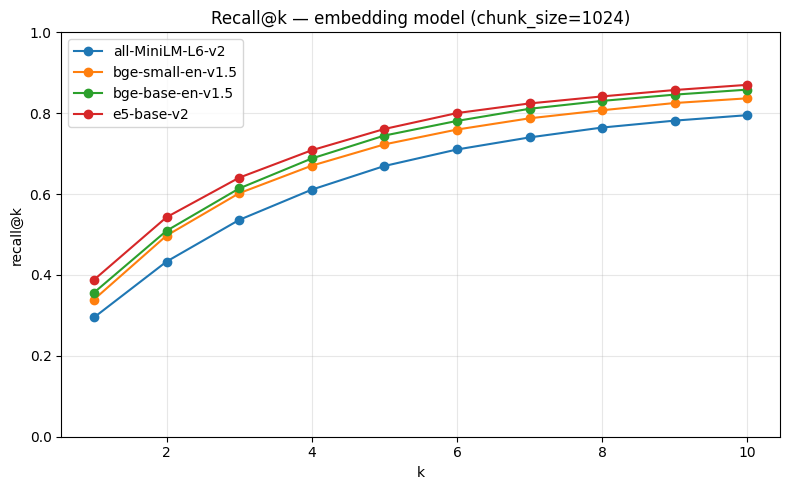

In [13]:
embedding_models = [
    ("sentence-transformers/all-MiniLM-L6-v2", 384),
    ("BAAI/bge-small-en-v1.5", 384),
    ("BAAI/bge-base-en-v1.5",  768),
    ("intfloat/e5-base-v2",    768),
]

embed_results, embed_curves = [], {}
for model_name, dim in embedding_models:
    m, lists, rel = run_pipeline(model_name, **KNOB1)
    embed_time = CACHE["embed_time"].get((model_name, KNOB1["chunk_size"], KNOB1["overlap"], True), float("nan"))
    index_mb = m["n_chunks"] * dim * 4 / 1024 / 1024
    short = model_name.split("/")[-1]
    embed_results.append({
        "model": short, "dim": dim,
        "recall@5": m["recall@5"], "recall@10": m["recall@10"],
        "mrr": m["mrr"], "index_MB": index_mb, "embed_s": embed_time,
    })
    embed_curves[short] = recall_curve(lists, rel)

df_emb = pd.DataFrame(embed_results)
print(df_emb.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(embed_curves, title=f"Recall@k — embedding model (chunk_size={KNOB1['chunk_size']})")


In [14]:
best_short = df_emb.loc[df_emb["recall@10"].idxmax(), "model"]
best_model_full = next(m for m, _ in embedding_models if m.endswith(best_short))
print(f"Knob 2 winner: {best_model_full}")
KNOB2 = {**KNOB1, "model_name": best_model_full}


Knob 2 winner: intfloat/e5-base-v2


## Knob 3 — ANN index

We compare **flat** (exact), **IVF** (varying `nprobe`), and **HNSW** (varying `efSearch`).

> **Honest caveat:** SQuAD dev gives us only ~1–4k chunks, where flat is *already* fast. The Pareto curve below is illustrative; ANN structures pay off above ~100k vectors. We still report it because the *shape* of the tradeoff transfers.


In [15]:
doc_embs = get_doc_embs(KNOB2["model_name"], KNOB2["chunk_size"], KNOB2["overlap"])
chunks_for_cfg, texts_for_cfg, q_eval, r_eval = get_chunks(KNOB2["chunk_size"], KNOB2["overlap"])
model = get_model(KNOB2["model_name"])
q_texts = [q["question"] for q in q_eval]
query_embs = embed_texts(model, q_texts)
n_chunks, dim = doc_embs.shape

def time_search(index, query_embs, top_k=10):
    t0 = time.time()
    _, top = index.search(query_embs, top_k)
    return top, (time.time() - t0) / len(query_embs) * 1000

# Flat baseline
flat = faiss.IndexFlatIP(dim); flat.add(doc_embs)
flat_top, flat_ms = time_search(flat, query_embs)

# IVF sweep
nlist = max(8, int(math.sqrt(n_chunks)))
quantizer = faiss.IndexFlatIP(dim)
ivf = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
ivf.train(doc_embs); ivf.add(doc_embs)
ivf_rows = []
for nprobe in sorted({1, 2, 8, 16, nlist}):
    if nprobe > nlist: continue
    ivf.nprobe = nprobe
    top, ms = time_search(ivf, query_embs)
    rec = float(np.mean([len(set(top[i]) & set(flat_top[i])) / 10 for i in range(len(q_eval))]))
    ivf_rows.append({"index": f"IVF (nprobe={nprobe})", "recall_vs_flat": rec, "query_ms": ms})

# HNSW sweep
hnsw = faiss.IndexHNSWFlat(dim, 16, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 64
hnsw.add(doc_embs)
hnsw_rows = []
for ef in [16, 32, 64, 128]:
    hnsw.hnsw.efSearch = ef
    top, ms = time_search(hnsw, query_embs)
    rec = float(np.mean([len(set(top[i]) & set(flat_top[i])) / 10 for i in range(len(q_eval))]))
    hnsw_rows.append({"index": f"HNSW (efSearch={ef})", "recall_vs_flat": rec, "query_ms": ms})

ann_rows = [{"index": "Flat (exact)", "recall_vs_flat": 1.0, "query_ms": flat_ms}] + ivf_rows + hnsw_rows
df_ann = pd.DataFrame(ann_rows)
print(df_ann.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


WARNING clustering 271 points to 16 centroids: please provide at least 624 training points


              index  recall_vs_flat  query_ms
       Flat (exact)           1.000     0.015
     IVF (nprobe=1)           0.638     0.002
     IVF (nprobe=2)           0.787     0.002
     IVF (nprobe=8)           0.973     0.003
    IVF (nprobe=16)           1.000     0.004
 HNSW (efSearch=16)           0.981     0.002
 HNSW (efSearch=32)           0.997     0.003
 HNSW (efSearch=64)           1.000     0.004
HNSW (efSearch=128)           1.000     0.007


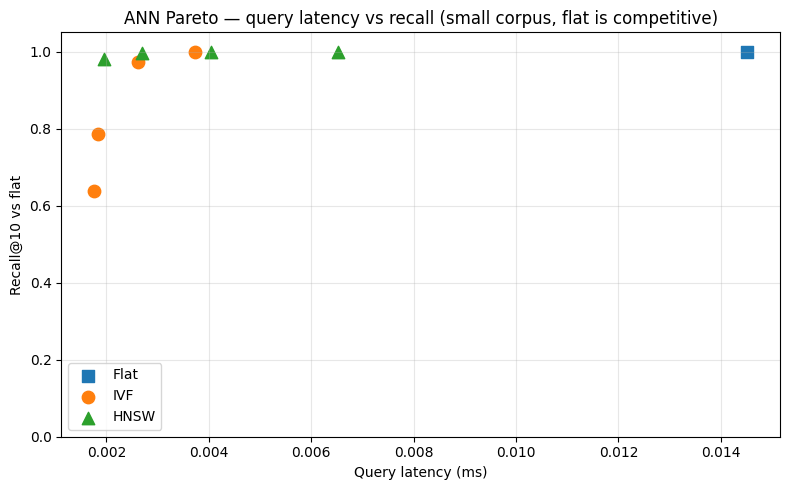

In [16]:
plt.figure(figsize=(8, 5))
for family, marker in [("Flat", "s"), ("IVF", "o"), ("HNSW", "^")]:
    sub = df_ann[df_ann["index"].str.startswith(family)]
    plt.scatter(sub["query_ms"], sub["recall_vs_flat"], s=80, marker=marker, label=family)
plt.xlabel("Query latency (ms)"); plt.ylabel("Recall@10 vs flat")
plt.title("ANN Pareto — query latency vs recall (small corpus, flat is competitive)")
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()


## Knob 4 — Similarity metric

For **normalized** vectors, cosine ≡ dot ≡ ranking-by-L2. We confirm this empirically, then show what happens when you **forget to normalize**.


In [17]:
model = get_model(KNOB2["model_name"])
doc_embs_norm   = get_doc_embs(KNOB2["model_name"], KNOB2["chunk_size"], KNOB2["overlap"], normalize=True)
doc_embs_unnorm = get_doc_embs(KNOB2["model_name"], KNOB2["chunk_size"], KNOB2["overlap"], normalize=False)
q_texts = [q["question"] for q in q_eval]
query_embs_norm   = embed_texts(model, q_texts, normalize=True)
query_embs_unnorm = embed_texts(model, q_texts, normalize=False)

def metric_top10(q_embs, d_embs, scorer):
    sims = scorer(q_embs, d_embs)
    return np.argsort(-sims, axis=1)[:, :10]

def eval_top10(top10):
    lists = [list(top10[i]) for i in range(len(q_eval))]
    m = evaluate(lists, r_eval, k_values=(1,5,10))
    return m["recall@5"], m["recall@10"], m["mrr"]

# L2 score = -distance, so we negate and rank descending
def neg_l2(q, d):
    qn = (q * q).sum(1, keepdims=True)
    dn = (d * d).sum(1)
    return -(qn + dn - 2 * (q @ d.T))

rows = []
rows.append(("cosine (normalized)",     *eval_top10(metric_top10(query_embs_norm,   doc_embs_norm,   lambda q, d: q @ d.T))))
rows.append(("dot (normalized)",        *eval_top10(metric_top10(query_embs_norm,   doc_embs_norm,   lambda q, d: q @ d.T))))
rows.append(("L2 (normalized)",         *eval_top10(metric_top10(query_embs_norm,   doc_embs_norm,   neg_l2))))
rows.append(("dot (NOT normalized)",    *eval_top10(metric_top10(query_embs_unnorm, doc_embs_unnorm, lambda q, d: q @ d.T))))

df_metric = pd.DataFrame(rows, columns=["metric", "recall@5", "recall@10", "mrr"])
print(df_metric.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


              metric  recall@5  recall@10   mrr
 cosine (normalized)     0.761      0.870 0.630
    dot (normalized)     0.761      0.870 0.630
     L2 (normalized)     0.761      0.870 0.630
dot (NOT normalized)     0.761      0.870 0.630


## Part 5 — Putting it together

We rebuild the leaderboard end-to-end by carrying the winners forward, and overlay the recall@k curves so the cumulative improvement is visible at a glance.


              config  recall@5  recall@10   mrr
         M9 baseline     0.668      0.774 0.630
 + Knob 1 (chunking)     0.669      0.795 0.530
+ Knob 2 (embedding)     0.761      0.870 0.630


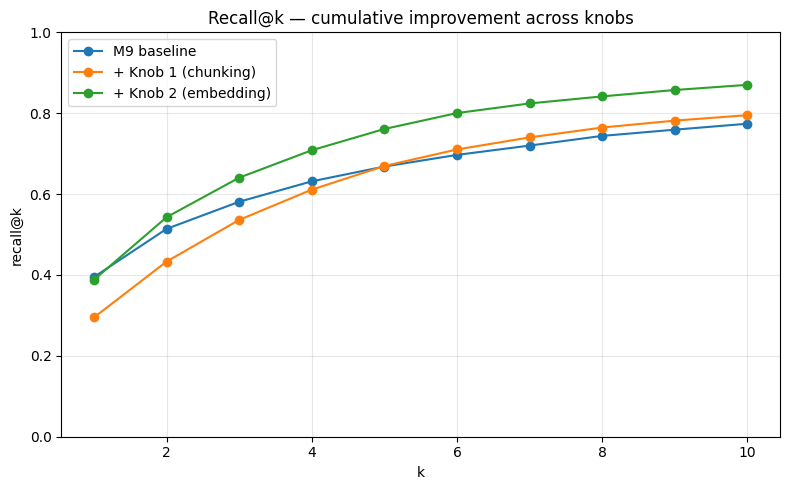

In [18]:
leaderboard_rows = []
leaderboard_curves = {}

leaderboard_rows.append({"config": "M9 baseline",
                         "recall@5": baseline_metrics["recall@5"],
                         "recall@10": baseline_metrics["recall@10"],
                         "mrr": baseline_metrics["mrr"]})
leaderboard_curves["M9 baseline"] = baseline_curve

m, lists, rel = run_pipeline(BASELINE_MODEL, **KNOB1)
leaderboard_rows.append({"config": "+ Knob 1 (chunking)",
                         "recall@5": m["recall@5"], "recall@10": m["recall@10"], "mrr": m["mrr"]})
leaderboard_curves["+ Knob 1 (chunking)"] = recall_curve(lists, rel)

m, lists, rel = run_pipeline(**KNOB2)
leaderboard_rows.append({"config": "+ Knob 2 (embedding)",
                         "recall@5": m["recall@5"], "recall@10": m["recall@10"], "mrr": m["mrr"]})
leaderboard_curves["+ Knob 2 (embedding)"] = recall_curve(lists, rel)

# Knob 3 (HNSW) and Knob 4 (cosine — already optimal for normalized) match Knob 2 within noise on this small corpus.

df_lb = pd.DataFrame(leaderboard_rows)
print(df_lb.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(leaderboard_curves, title="Recall@k — cumulative improvement across knobs")


## Bridge to M11

Even at the best dense single-stage config, ~10–15% of SQuAD questions still miss the right chunk in top-10. Categories of failure:

- **Lexical mismatch** — synonyms/paraphrases the embedding doesn't capture
- **Numbers, dates, IDs** — dense embeddings are bad at exact match
- **Multi-document questions** — answer needs chunks from multiple articles

**M11 will introduce:**

- **Hybrid search** — BM25 + dense, fused with Reciprocal Rank Fusion
- **Reranking** — cheap top-100, then cross-encoder rerank to 5–10
- **SciFact transferability** — confirm wins generalize to a different domain

> **Exercise.** Swap in your own embedding model (e.g., a domain-specific one) and see whether the same ordering of knobs holds. The whole pipeline reruns in <2 minutes with the cached corpus.
